Memproses STEAD (50k) (Komponen Z saja)...


Memproses STEAD (Lit) (Komponen Z saja)...


Memproses UUSS (Test) (Komponen Z saja)...


Memproses Ukraine (Komponen Z saja)...


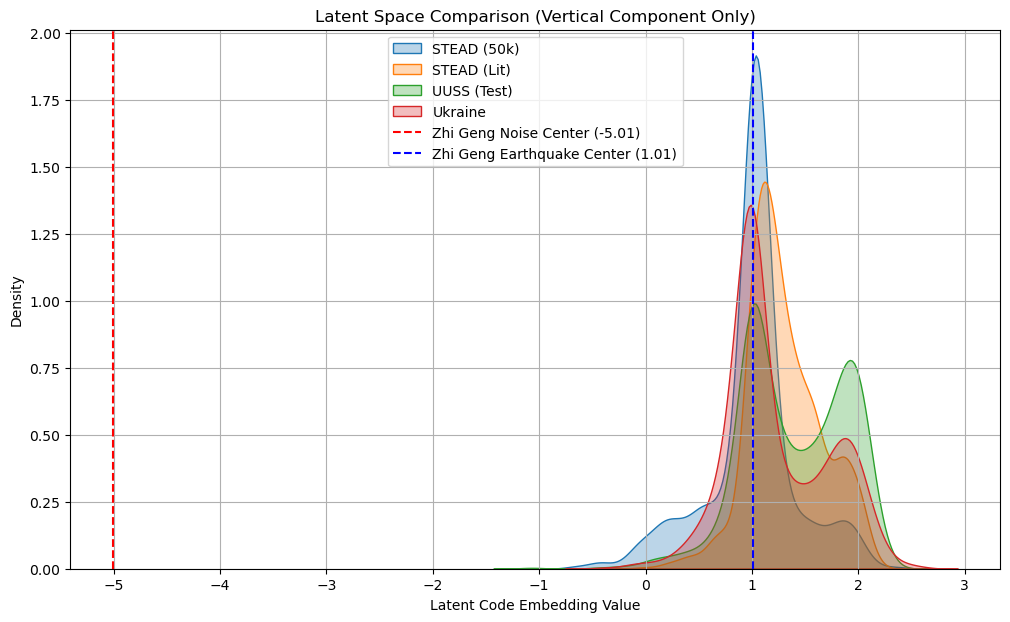

In [7]:
# -*- coding: utf-8 -*-
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import keras

# Path ke Library
library_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/Library'
if library_path not in sys.path:
    sys.path.append(library_path)
import utils

# Muat model
final_model_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
embedding_model = keras.models.load_model(filepath=final_model_path)

def normalize_signal(x):
    x = np.array(x, dtype=float)
    m = np.max(np.abs(x))
    return x / m if m != 0 else x

# Path dataset
datasets = {
    "STEAD (50k)": '/Volumes/Extreme SSD/stream_stead/data_stead/STEAD_25000_MCUQuake_1C.json',
    "STEAD (Lit)": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "UUSS (Test)": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}

plt.figure(figsize=(12, 7))

for name, path in datasets.items():
    print(f"Memproses {name} (Komponen Z saja)...")
    with open(path, 'r') as f:
        data = json.load(f)
    
    keys = list(data.keys())[:1000]
    embs = []
    for k in tqdm(keys, desc=f"Ekstraksi {name}", leave=False):
        # Selalu ambil 'Z', baik data 1C maupun 3C
        Z = normalize_signal(data[k]["Z"][:700])
        embs.append(utils.latent_codes_1D(Z, embedding_model))
    
    sns.kdeplot(np.array(embs).flatten(), label=name, fill=True, alpha=0.3)

plt.axvline(x=-5.01, color='red', linestyle='--', label="Zhi Geng Noise Center (-5.01)")
plt.axvline(x=1.01, color='blue', linestyle='--', label="Zhi Geng Earthquake Center (1.01)")
plt.title("Latent Space Comparison (Vertical Component Only)")
plt.xlabel("Latent Code Embedding Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()